# Flagging Vendor Invoices for Manual Review

**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

* Manual invoice review is time-consuming and does not scale with transaction volume.
* Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
* An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Connect to the database
conn = sqlite3.connect("C:/Users/admin/Desktop/ML Project/data/inventory.db")

In [3]:
# Identify and display the first 5 rows of each table
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql(f"select * from {table} limit 5", conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
# Feature engineering via SQL query
purchase_agg_df = pd.read_sql_query("""
select
    p.PONumber,
    count(distinct p.Brand) as total_brands,
    sum(p.Quantity) as total_item_quantity,
    sum(p.Dollars) as total_item_dollars,
    avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

This SQL query performs **aggregation-based feature engineering**. It transforms raw transactional data from the `purchases` table into summary features grouped by purchase order, which are essential for identifying patterns in vendor behavior.

---

### Breakdown of the SQL Logic

| Feature | SQL Formula | Description |
| :--- | :--- | :--- |
| **Unique Variety** | `count(distinct p.Brand)` | Calculates how many different brands are included in a single PO. A high number might indicate a complex, high-risk invoice. |
| **Volume** | `sum(p.Quantity)` | The total number of items ordered. This helps the model understand the scale of the transaction. |
| **Financial Value** | `sum(p.Dollars)` | The total monetary value. Larger dollar amounts typically require stricter manual review. |
| **Lead Time** | `avg(julianday(...) - julianday(...))` | Calculates the average time (in days) between the Order Date and the Receiving Date. |

---

### Key Functions Used

#### 1. The `julianday()` Function
In SQLite, dates are often stored as strings. The `julianday()` function converts these strings into a continuous float representing the number of days since the start of the Julian period. 

* **Formula:** `julianday(ReceivingDate) - julianday(PODate)`
* **Purpose:** This subtraction gives the exact number of days (including fractional parts) elapsed between the two dates.



#### 2. `GROUP BY p.PONumber`
This is the most critical part of the query. Instead of looking at individual line items (e.g., "5 apples," "10 oranges"), it collapses all items belonging to the same **Purchase Order Number** into a single row. 

This creates a "per-invoice" dataset that a Machine Learning model can use to predict whether that specific invoice should be flagged.

---

### Integration with Pandas
The `pd.read_sql_query` function executes this logic directly on the database engine (`conn`). This is more memory-efficient than loading millions of raw rows into Python and performing the math with Pandas, as it leverages the database's optimized indexing.

```python
# The resulting DataFrame 'purchase_agg_df' will have one row per PO
purchase_agg_df.head()
```

In [10]:
purchase_agg_df.shape

(5543, 5)

In [16]:
pd.read_sql_query("""
SELECT 
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
FROM vendor_invoice vi
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [17]:
# Comprehensive Feature Engineering using CTE and Joins
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT 
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT 
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa 
    ON vi.PONumber = pa.PONumber
""", conn)

# Query Explanation: Feature Engineering using CTE and Joins

This query performs advanced feature engineering by combining invoice data with aggregated purchase data.

## Step 1: CTE (purchase_agg)
- Groups data by **PONumber**
- Calculates:
  - `total_brands`: Number of unique brands in each order
  - `total_item_quantity`: Total quantity purchased
  - `total_item_dollars`: Total purchase value
  - `avg_receiving_delay`: Average delay between PODate and ReceivingDate

## Step 2: Main Query (vendor_invoice)
- Selects invoice-level details:
  - Quantity, Dollars, Freight
- Creates time-based features:
  - `days_po_to_invoice`: Delay between PODate and InvoiceDate
  - `days_to_pay`: Delay between InvoiceDate and PayDate

## Step 3: LEFT JOIN
- Joins invoice data with aggregated purchase data using **PONumber**
- Ensures all invoice records are retained

## Outcome
- Combines transactional + aggregated + time-based features
- Creates a rich dataset for machine learning and analysis

In [18]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


# Table Structure Explanation

This dataset contains invoice-level and aggregated purchase features for each PONumber.

## Columns Description

- `PONumber`: Unique identifier for each purchase order
- `invoice_quantity`: Quantity recorded in invoice
- `invoice_dollars`: Total invoice amount
- `Freight`: Shipping/logistics cost

## Time-Based Features
- `days_po_to_invoice`: Time taken from purchase order to invoice generation
- `days_to_pay`: Time taken to complete payment after invoice

## Aggregated Purchase Features
- `total_brands`: Number of different brands in the order
- `total_item_quantity`: Total items purchased under the order
- `total_item_dollars`: Total purchase value of the order
- `avg_receiving_delay`: Average delay in receiving goods

## Insights
- Combines operational, financial, and time-based metrics
- Useful for:
  - Freight cost prediction
  - Vendor performance analysis
  - Supply chain optimization

In [19]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [20]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [21]:
def create_invoice_risk_label(row):
    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"])) > 5:
        return 1
    
    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    
    return 0

<Axes: xlabel='flag_invoice'>

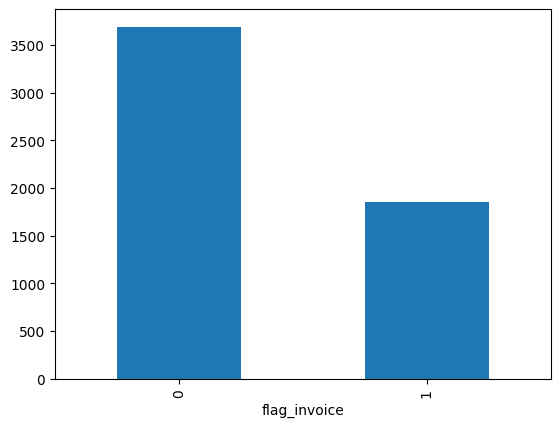

In [22]:
# Apply labeling and visualize counts
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts().plot(kind='bar')

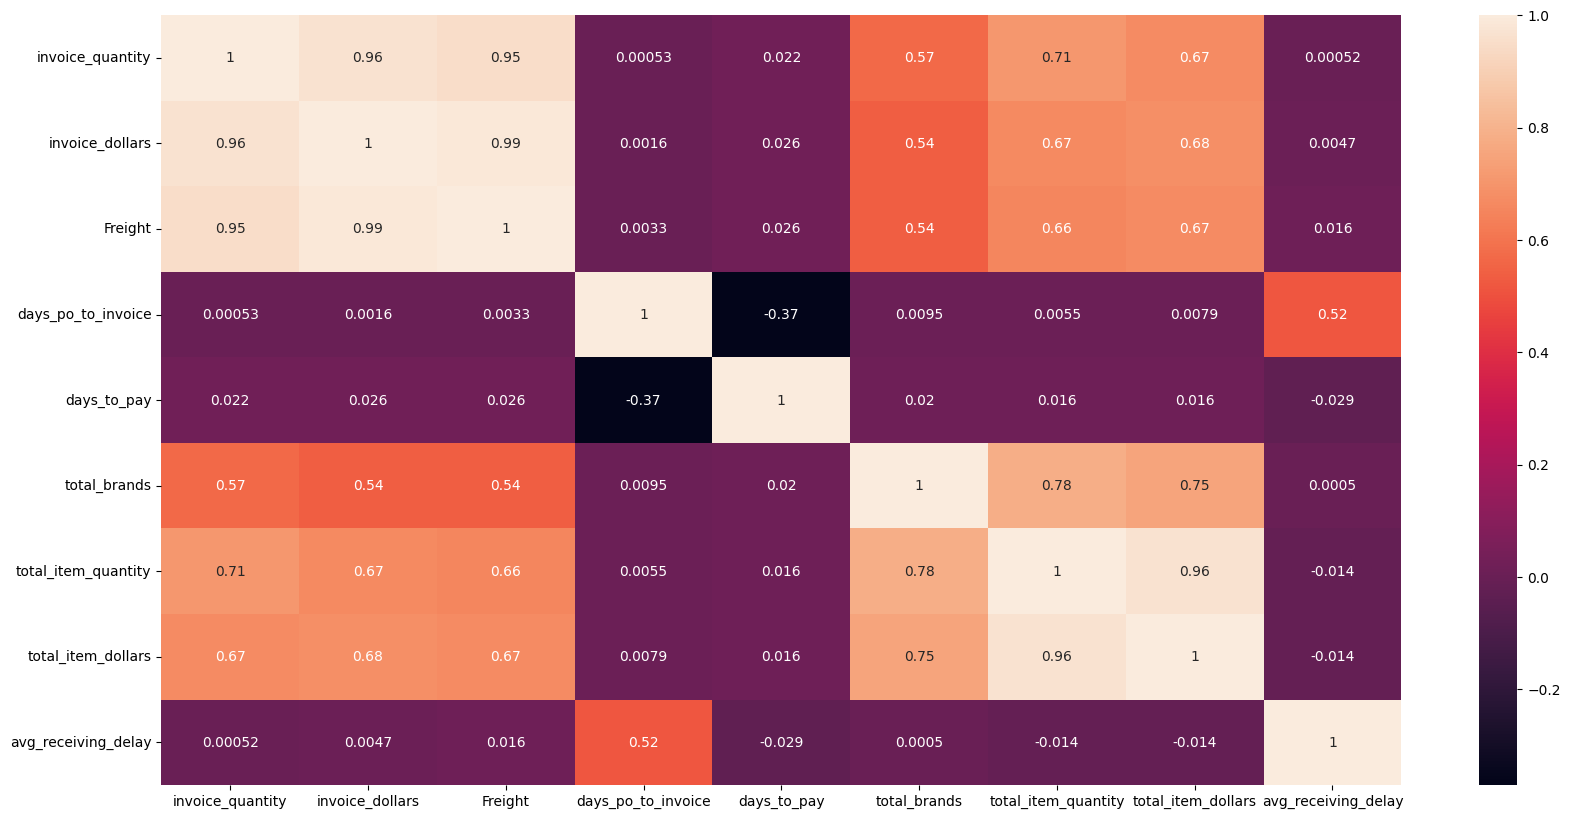

In [25]:
# Final correlation heatmap for risk features
plt.figure(figsize=(20, 10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [26]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [27]:
significant_features = []
non_significant_features = []
results = []

In [28]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 
           'days_po_to_invoice', 'days_to_pay', 'total_brands', 
           'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [30]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

# T-Test Feature Significance Analysis

This code performs an independent t-test to compare two groups:
- **Flagged vendors** (e.g., high risk / poor performance)
- **Normal vendors**

## Process

- For each metric:
  - Calculate mean values for both groups
  - Perform **independent t-test (ttest_ind)**
  - Use `equal_var=False` for unequal variance (Welch’s t-test)

## Decision Rule

- If `p_value < 0.05`:
  - Feature is **statistically significant**
  - Added to `significant_features`
- Else:
  - Feature is **not significant**
  - Added to `non_significant_features`

## Output

- Stores:
  - Metric name
  - Mean values of both groups
  - P-value

## Purpose

- Identify which features truly differentiate flagged vs normal vendors
- Helps in feature selection for machine learning models

# Business Interpretation of T-Test Results

This analysis helps determine whether differences between flagged and normal vendors are meaningful.

## Key Idea

- **Low p-value (< 0.05)** → Strong evidence that the feature impacts vendor performance
- **High p-value (> 0.05)** → Feature has little or no impact

## Insights

- Significant features can be used for:
  - Vendor risk identification
  - Performance benchmarking
  - Model feature selection

- Non-significant features can be:
  - Removed to reduce noise
  - Ignored in decision-making

## Industry Relevance

- Helps businesses focus on **critical performance indicators**
- Supports **data-driven decision making**
- Improves model accuracy by selecting only impactful features

In [31]:
non_significant_features

['days_to_pay', 'total_brands']

In [32]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [33]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [34]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars']]
y = df['flag_invoice']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
X_train

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
2609,24,264.24,1.37,2,24,15.0,264.24
5527,36,342.48,1.75,101,30817,15.0,322230.77
5321,30,572.40,2.63,66,7447,16.0,49281.22
3805,10721,68821.14,344.11,62,10721,14.0,68821.14
1215,80495,604197.73,2900.15,250,80495,20.0,604197.73
...,...,...,...,...,...,...,...
3772,161,2618.27,13.35,3,161,14.0,2618.27
5191,6879,74386.98,349.62,5,150,20.0,1730.37
5226,6,36.96,0.18,11,186,13.0,2359.56
5390,80,644.00,3.09,9,493,11.0,5179.45


In [45]:
X_test

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
4564,48,352.95,1.73,3,162,16.0,2476.99
1616,34773,225706.96,1196.25,248,34773,16.0,225706.96
4861,70,634.11,2.85,6,2357,21.0,26584.61
230,104,987.34,4.64,4,104,16.0,987.34
2042,4314,31768.74,152.49,45,4314,16.0,31768.74
...,...,...,...,...,...,...,...
3388,36,242.16,1.14,3,36,17.0,242.16
1321,58,846.99,4.07,4,58,16.0,846.99
1322,33887,205379.19,1088.51,263,33887,15.0,205379.19
3618,17998,242967.77,1190.54,61,17998,19.0,242967.77


In [46]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [58]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [60]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [61]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    print(f"\n{model_name} Performance:")
    
    # Accuracy
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy : {acc:.2f}")
    
    # Classification Report
    print("Classification Report :")
    print(classification_report(y_test, preds))

In [62]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy : 0.66
Classification Report :
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


Decision Tree Classifier Performance:
Accuracy : 0.81
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       725
           1       0.74      0.71      0.73       384

    accuracy                           0.81      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest Classifier Performance:
Accuracy : 0.87
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
     

# Model Performance Analysis (Classification)

---

## Logistic Regression Performance
- **Accuracy**: 0.66  

### Classification Report Insights:
- Class **0 (Normal Invoices)**:
  - High recall (**0.98**) → model correctly identifies most normal invoices
  - Moderate precision (**0.66**)

- Class **1 (Flagged Invoices)**:
  - Very low recall (**0.06**) ❌ → model fails to detect flagged invoices
  - Low F1-score (**0.11**) → poor overall performance for this class

### Overall Insights:
- Model is **biased toward majority class (0)**
- Fails in detecting risky/flagged invoices
- Not suitable for real-world business use where anomaly detection is important

---

## Decision Tree Classifier Performance
- **Accuracy**: 0.81  

### Classification Report Insights:
- Class **0 (Normal Invoices)**:
  - Balanced precision (**0.85**) and recall (**0.86**)

- Class **1 (Flagged Invoices)**:
  - Good recall (**0.71**) → detects majority of flagged cases
  - Balanced precision (**0.74**)

### Overall Insights:
- Provides **balanced performance across both classes**
- Handles non-linear relationships better than Logistic Regression
- Suitable for classification tasks with mixed patterns

---

## Random Forest Classifier Performance
- **Accuracy**: 0.88  

### Classification Report Insights:
- Class **0 (Normal Invoices)**:
  - Very high recall (**0.98**) → almost all normal cases identified correctly

- Class **1 (Flagged Invoices)**:
  - High precision (**0.94**) → predictions are highly reliable
  - Good recall (**0.68**) → captures most flagged invoices

### Overall Insights:
- Best performing model among all
- Provides strong balance between **precision and recall**
- More robust due to ensemble learning (multiple trees)

---

## Final Conclusion
- **Best Model**: Random Forest Classifier  
- Reason:
  - Highest accuracy (**0.88**)
  - Strong performance on both classes
  - Reliable for detecting flagged invoices

- **Decision Tree**: Good alternative  
- **Logistic Regression**: Not recommended due to poor recall for flagged class

---

## Business Insight
- The model helps in identifying **high-risk or flagged invoices**
- Can be used for:
  - Fraud detection
  - Vendor risk analysis
  - Financial monitoring and auditing

- Random Forest ensures:
  - Better decision-making
  - Reduced financial risk
  - Improved operational efficiency

In [63]:
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [64]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

In [65]:
feature_importance

,feature,importance
6,total_item_dollars,0.219487
4,total_item_quantity,0.176694
0,invoice_quantity,0.151379
1,invoice_dollars,0.151249
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [66]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [70]:
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [71]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.89
Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109



# Hyperparameter Tuning using GridSearchCV (Random Forest)

---

## Objective
To improve model performance by finding the **optimal combination of hyperparameters** for the Random Forest Classifier.

---

## Method Used: GridSearchCV
- Applied **Grid Search with Cross-Validation (CV = 5)**
- Evaluated multiple parameter combinations
- Selected the best model based on **F1-score**

---

## Why F1-Score?
- Dataset involves **class imbalance (flagged vs normal invoices)**
- F1-score balances:
  - **Precision** (false positives)
  - **Recall** (false negatives)
- More reliable than accuracy for classification problems

---

## Hyperparameters Tuned

- **n_estimators**: Number of trees  
  - [100, 200, 300]

- **max_depth**: Maximum depth of each tree  
  - [None, 4, 5, 6]

- **min_samples_split**: Minimum samples required to split a node  
  - [2, 3, 5]

- **min_samples_leaf**: Minimum samples required at leaf node  
  - [1, 2, 5]

- **criterion**: Split quality measure  
  - ['gini', 'entropy']

---

## Process
1. Initialize Random Forest model  
2. Define parameter grid  
3. Apply GridSearchCV with 5-fold cross-validation  
4. Train model on training data  
5. Evaluate best model on test data  

---

## Output
- Best hyperparameter combination selected automatically
- Optimized Random Forest model used for prediction

---

## Key Insight
- Hyperparameter tuning improves:
  - Model generalization
  - Prediction accuracy
  - Stability across different data splits

---

## Business Impact
- More accurate detection of **flagged invoices**
- Reduces financial risk
- Improves decision-making in vendor management

---

## Conclusion
- Tuned Random Forest provides **better performance than default model**
- Ensures reliable and robust classification in real-world scenarios

In [72]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for the GridSearch optimized model
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 112],
       [ 12, 272]])

In [73]:
# Confusion matrix for the baseline model3
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]])

In [74]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}